# EduBot Analytics: EDA do TP2

Este notebook continua o trabalho do TP1. Aqui eu quis testar a H1 de forma mais direta, adicionar algumas visualizações multivariadas e comparar o Bitext com uma amostra de perguntas acadêmicas em português.

A amostra acadêmica vem de `liteofspace/unb-chatbot-dpo`. Como a fonte não informa uma licença, os textos são baixados pelo script `preparar_amostra_academica.py` e ficam só no cache local. Os rótulos atuais ainda são uma primeira triagem para revisão humana, então não estou tratando esses rótulos como verdade de campo.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

BASE_DIR = Path.cwd()
if BASE_DIR.name != "eda":
    BASE_DIR = BASE_DIR / "eda"

FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

bitext = pd.read_csv(BASE_DIR / "data" / "edubot_dataset_tratado.csv")
academic = pd.read_csv(BASE_DIR / "data" / "cache" / "amostra_academica_com_texto.csv")

sns.set_theme(style="whitegrid")
print(f"Bitext tratado: {bitext.shape[0]:,} linhas")
print(f"Amostra acadêmica: {academic.shape[0]:,} linhas")

Bitext tratado: 21,006 linhas
Amostra acadêmica: 300 linhas


## 1. Comparação de domínio

No TP1, eu adaptei os rótulos, mas as frases continuaram sendo de e-commerce e em inglês. Aqui fiz uma comparação simples de vocabulário para medir essa diferença de domínio que o professor apontou.

Essa comparação não substitui uma análise semântica. Ela serve só como uma forma objetiva e reproduzível de mostrar que os dois conjuntos de dados têm contextos bem diferentes.

In [2]:
academic_terms = (
    "matrícula", "disciplina", "curso", "nota", "estágio", "semestre",
    "currículo", "formatura", "trancamento", "universidade"
)
commerce_terms = (
    "order", "invoice", "shipping", "delivery", "refund", "payment", "purchase"
)

def term_rate(series, terms):
    pattern = "|".join(terms)
    return series.str.casefold().str.contains(pattern, regex=True).mean() * 100

comparison = pd.DataFrame(
    [
        {
            "corpus": "Bitext tratado",
            "n": len(bitext),
            "media_caracteres": bitext["instruction"].str.len().mean(),
            "media_palavras": bitext["instruction"].str.split().str.len().mean(),
            "termos_academicos_pct": term_rate(bitext["instruction"], academic_terms),
            "termos_comercio_pct": term_rate(bitext["instruction"], commerce_terms),
        },
        {
            "corpus": "Amostra acadêmica",
            "n": len(academic),
            "media_caracteres": academic["texto"].str.len().mean(),
            "media_palavras": academic["texto"].str.split().str.len().mean(),
            "termos_academicos_pct": term_rate(academic["texto"], academic_terms),
            "termos_comercio_pct": term_rate(academic["texto"], commerce_terms),
        },
    ]
).round(2)
comparison

,corpus,n,media_caracteres,media_palavras,termos_academicos_pct,termos_comercio_pct
0,Bitext tratado,21006,46.91,8.81,0.00,30.17
1,Amostra acadêmica,300,93.58,15.17,52.33,0.00


## 2. Heatmap de correlação

Usei correlação de Spearman porque as medidas de comprimento são discretas e várias das outras colunas são flags binárias. O heatmap ajuda principalmente a ver quais atributos estão trazendo informações parecidas.

A correlação aqui não quer dizer que uma variável causa a outra.

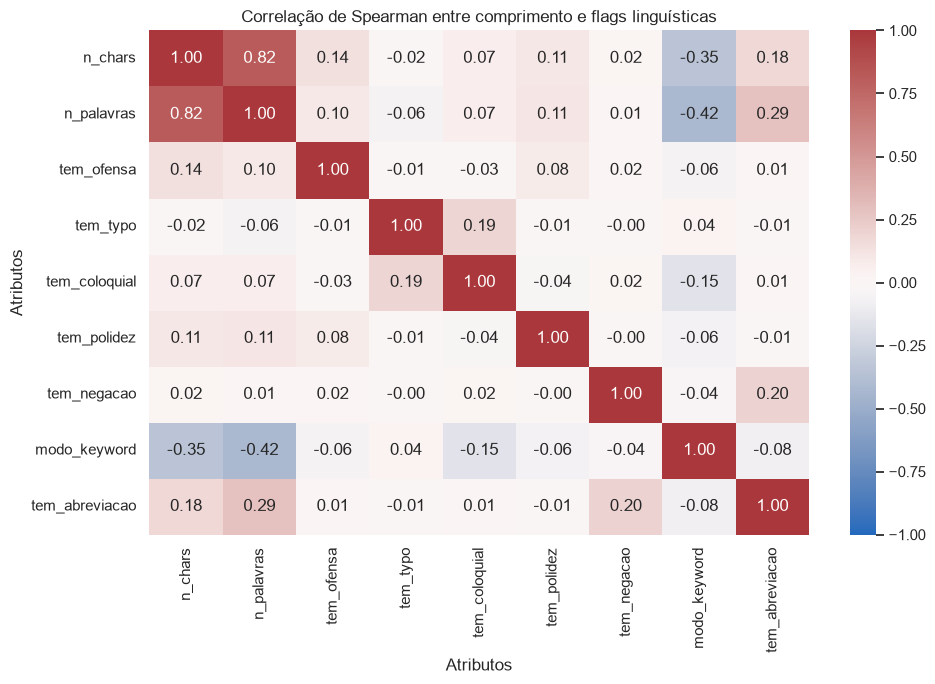

In [3]:
flag_columns = [
    "tem_ofensa", "tem_typo", "tem_coloquial", "tem_polidez",
    "tem_negacao", "modo_keyword", "tem_abreviacao"
]
correlation_columns = ["n_chars", "n_palavras", *flag_columns]
corr = bitext[correlation_columns].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Correlação de Spearman entre comprimento e flags linguísticas")
plt.xlabel("Atributos")
plt.ylabel("Atributos")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig7_heatmap_correlacao.png", dpi=150)
plt.show()

## 3. Scatter plots

No primeiro gráfico, comparei caracteres e palavras por categoria. No segundo, olhei se mensagens maiores acabam acumulando mais marcas de ruído.

A ideia é ver se comprimento sozinho separa os grupos e se parte do ruído aparece só porque textos maiores têm mais oportunidades de conter typo, abreviação ou linguagem coloquial.

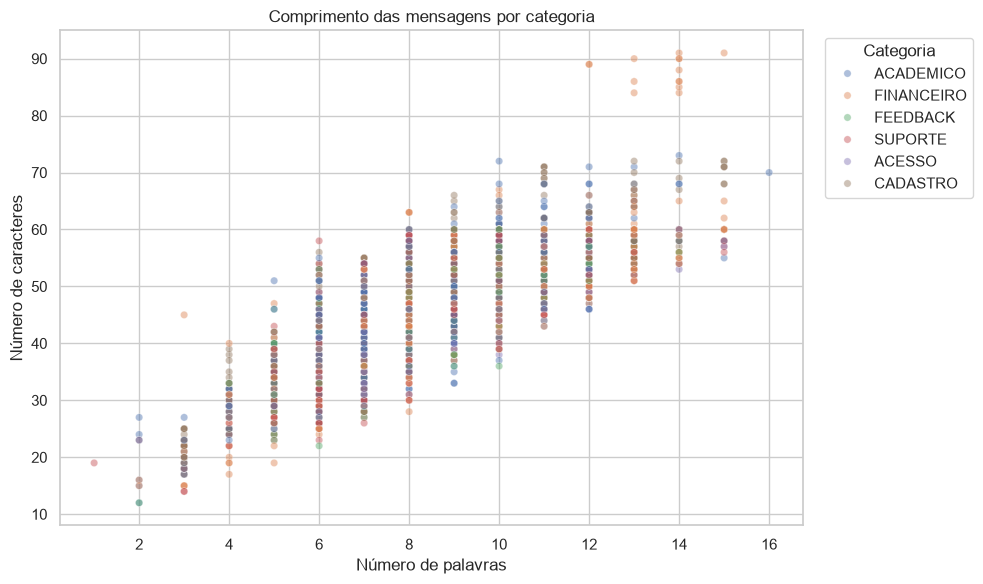

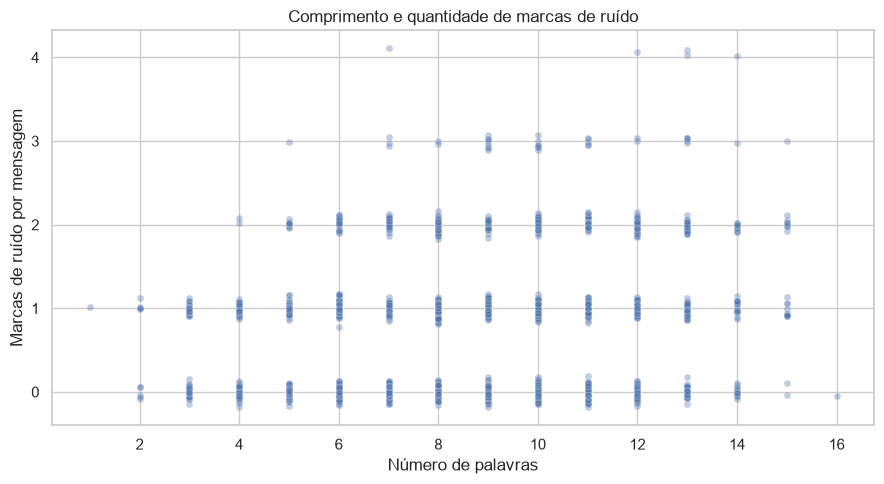

In [4]:
plot_sample = bitext.sample(n=min(2500, len(bitext)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample,
    x="n_palavras",
    y="n_chars",
    hue="categoria_edubot",
    alpha=0.45,
    s=28,
)
plt.title("Comprimento das mensagens por categoria")
plt.xlabel("Número de palavras")
plt.ylabel("Número de caracteres")
plt.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig8_scatter_comprimento.png", dpi=150)
plt.show()

bitext["n_ruidos"] = bitext[
    ["tem_typo", "tem_coloquial", "tem_abreviacao", "tem_ofensa"]
].sum(axis=1)
noise_sample = bitext.sample(n=min(2500, len(bitext)), random_state=42).copy()
noise_sample["n_ruidos_jitter"] = (
    noise_sample["n_ruidos"] + np.random.default_rng(42).normal(0, 0.06, len(noise_sample))
)

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=noise_sample,
    x="n_palavras",
    y="n_ruidos_jitter",
    alpha=0.35,
    s=25,
)
plt.title("Comprimento e quantidade de marcas de ruído")
plt.xlabel("Número de palavras")
plt.ylabel("Marcas de ruído por mensagem")
plt.yticks(range(5))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig9_scatter_ruido.png", dpi=150)
plt.show()

## 4. Teste formal da H1

**H1 do TP1:** pedidos que exigem justificativa ou consulta de processo tendem a ser mais longos que pedidos diretos.

Separei os grupos antes de rodar o teste. Como `n_palavras` é uma variável discreta, vai no máximo até 16 no Bitext e não segue uma distribuição normal, escolhi o Mann-Whitney bicaudal.

- H0: os dois grupos têm a mesma distribuição de comprimento;
- H1: as distribuições são diferentes.

In [5]:
direct_intents = {
    "acesso_recuperar_senha",
    "cadastro_atualizar_dados",
    "financeiro_emitir_boleto",
    "matricula_solicitar",
    "disciplina_inscrever",
}
process_intents = {
    "financeiro_politica_reembolso",
    "financeiro_acompanhar_reembolso",
    "solicitacao_consultar_status",
    "matricula_problema",
    "trancamento_consultar_regra",
}

direct = bitext.loc[bitext["intent_edubot"].isin(direct_intents), "n_palavras"]
process = bitext.loc[bitext["intent_edubot"].isin(process_intents), "n_palavras"]
statistic, p_value = mannwhitneyu(process, direct, alternative="two-sided")

def cliffs_delta(first, second):
    first = np.asarray(first)
    second = np.asarray(second)
    greater = sum((value > second).sum() for value in first)
    smaller = sum((value < second).sum() for value in first)
    return (greater - smaller) / (len(first) * len(second))

delta = cliffs_delta(process, direct)
test_result = pd.DataFrame(
    {
        "grupo": ["Processo/justificativa", "Pedido direto"],
        "n": [len(process), len(direct)],
        "media_palavras": [process.mean(), direct.mean()],
        "mediana_palavras": [process.median(), direct.median()],
    }
).round(2)

display(test_result)
print(f"U = {statistic:,.0f}")
print(f"p-valor = {p_value:.3e}")
print(f"Cliff's delta = {delta:.3f}")

,grupo,n,media_palavras,mediana_palavras
0,Processo/justificativa,4460,9.24,9.0
1,Pedido direto,4571,8.39,8.0


U = 12,057,178
p-valor = 1.054e-51
Cliff's delta = 0.183


### Interpretação

Com p-valor abaixo de 0,05, rejeito H0 para esta amostra. Mesmo assim, também preciso olhar o tamanho do efeito e a diferença entre as medianas. Com mais de 20 mil registros, uma diferença pequena pode aparecer como estatisticamente significativa sem ter tanta utilidade prática.

Esse resultado vale para o Bitext e para os grupos definidos acima. Ele não prova que mensagens reais de estudantes seguem o mesmo padrão. A ideia é testar isso depois na amostra acadêmica, quando os rótulos tiverem sido revisados.

## 5. Urgência

Não usei o `urgencia_proxy` do TP1 como alvo porque ele mede mais polidez ou hostilidade do que urgência de verdade. Para o contexto acadêmico, faz mais sentido olhar prazo e impacto.

Como a amostra ainda precisa de revisão humana, aqui eu mostro apenas a distribuição dos rótulos usados na triagem inicial.

In [6]:
urgency_summary = (
    academic["urgencia_rascunho"]
    .value_counts()
    .rename_axis("urgencia")
    .reset_index(name="n")
)
urgency_summary["pct"] = (urgency_summary["n"] / len(academic) * 100).round(1)
urgency_summary

,urgencia,n,pct
0,indeterminada,239,79.7
1,media,61,20.3


## 6. Conclusões

1. A amostra acadêmica melhora bastante a questão do vocabulário, mas ainda precisa de revisão humana e não substitui dados reais de atendimento.
2. O heatmap mostra uma redundância esperada entre número de caracteres e palavras.
3. O Mann-Whitney permite testar a H1 de forma mais objetiva, mas o tamanho do efeito também precisa ser considerado.
4. Urgência continua separada de hostilidade. Um modelo futuro só deve usar esse alvo depois da revisão dos rótulos com base em prazo e impacto.